📊 Loading reduced features dataset...
✅ Dataset loaded: 15206 samples
   Features: 5
   Classes: [0 1 2]
   Class distribution:
Class
1    8028
0    3808
2    3370
Name: count, dtype: int64

📂 Splitting dataset (70/30)...
   Training samples: 10644
   Testing samples: 4562

⚖️  Scaling features...
🤖 TRAINING ALL MODELS

🔄 Training Logistic Regression...
   ✅ Accuracy: 77.01%

🔄 Training Decision Tree...
   ✅ Accuracy: 85.23%

🔄 Training Random Forest...
   ✅ Accuracy: 88.80%

🔄 Training SVM...
   ✅ Accuracy: 85.12%

🔄 Training Naive Bayes...
   ✅ Accuracy: 77.01%

🔄 Training K-Nearest Neighbors...
   ✅ Accuracy: 85.73%

🔄 Training ANN (MLP)...
   ✅ Accuracy: 87.90%

📊 MODEL COMPARISON - OVERALL PERFORMANCE
              Model  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)
      Random Forest     88.798772      88.749287   88.798772     88.699844
          ANN (MLP)     87.900044      87.893788   87.900044     87.632801
K-Nearest Neighbors     85.729943      85.601623   85.72994

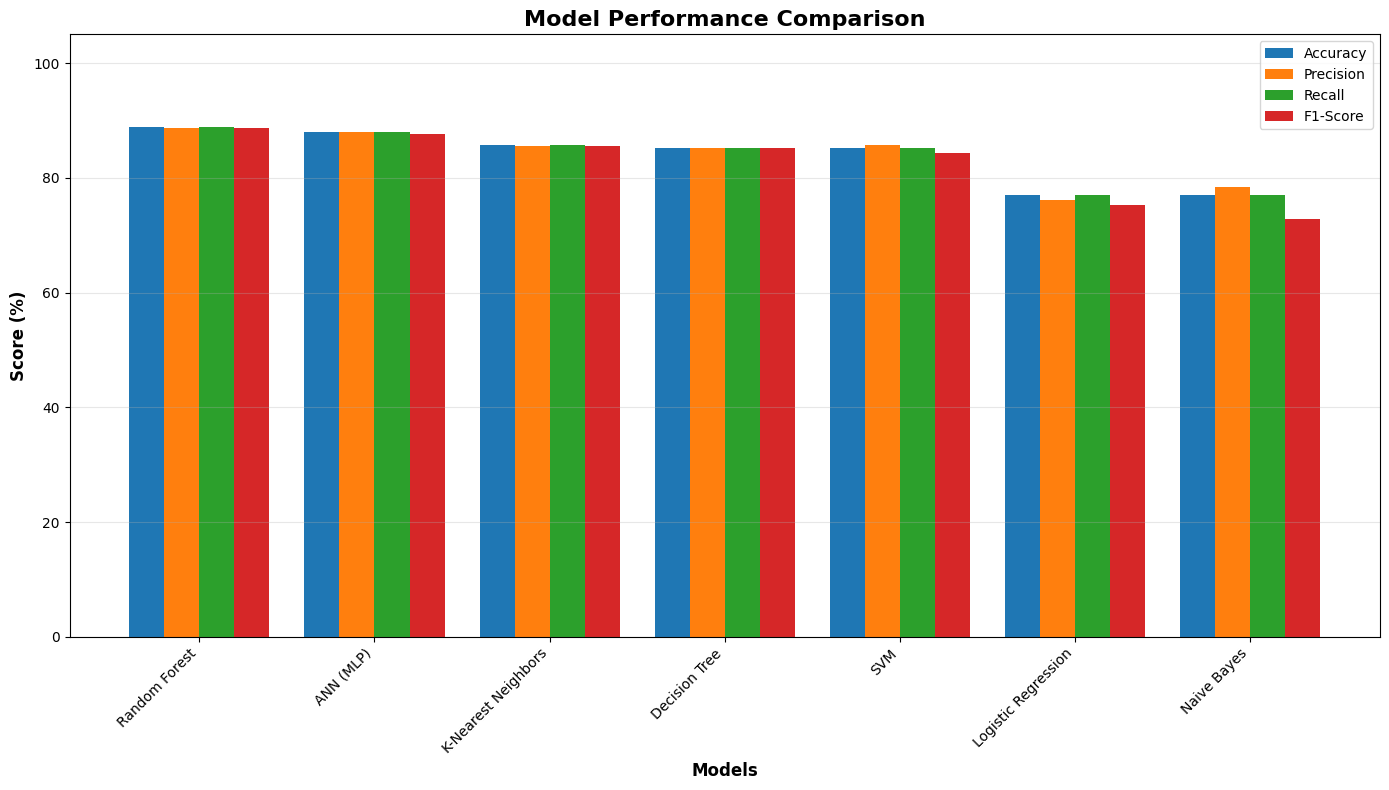

✅ All confusion matrices saved as 'all_confusion_matrices.png'



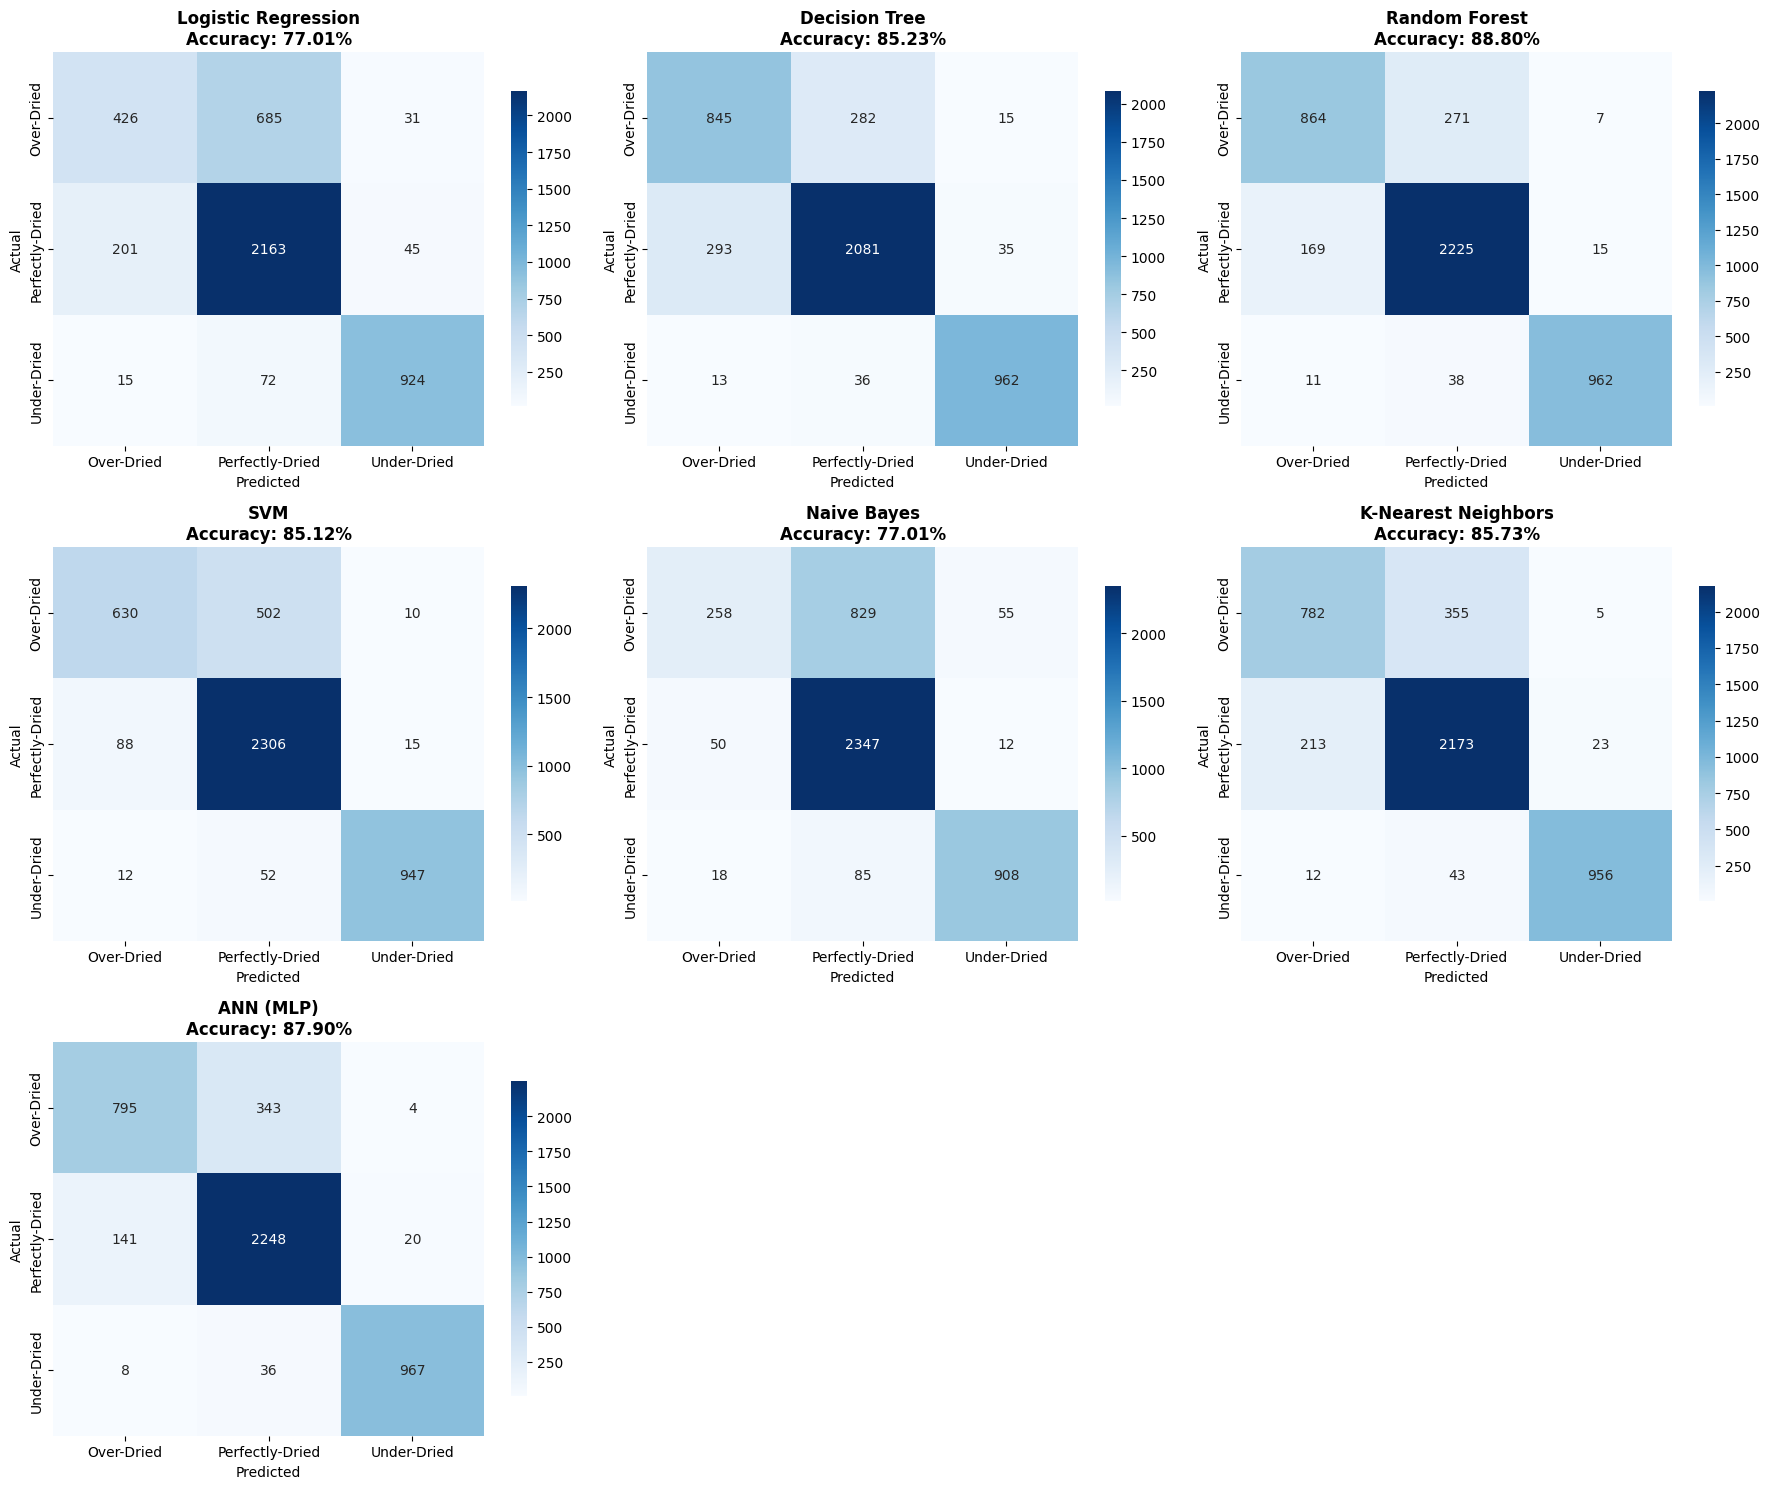

📊 PER-CLASS PERFORMANCE
              Model           Class Accuracy (%) Precision Recall F1-Score
Logistic Regression      Over-Dried        37.30    0.6636 0.3730   0.4776
Logistic Regression Perfectly-Dried        89.79    0.7408 0.8979   0.8118
Logistic Regression     Under-Dried        91.39    0.9240 0.9139   0.9189
      Decision Tree      Over-Dried        73.99    0.7341 0.7399   0.7370
      Decision Tree Perfectly-Dried        86.38    0.8674 0.8638   0.8656
      Decision Tree     Under-Dried        95.15    0.9506 0.9515   0.9511
      Random Forest      Over-Dried        75.66    0.8276 0.7566   0.7905
      Random Forest Perfectly-Dried        92.36    0.8781 0.9236   0.9003
      Random Forest     Under-Dried        95.15    0.9776 0.9515   0.9644
                SVM      Over-Dried        55.17    0.8630 0.5517   0.6731
                SVM Perfectly-Dried        95.72    0.8063 0.9572   0.8753
                SVM     Under-Dried        93.67    0.9743 0.9367   0.9551
 

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

# --- CONFIGURATION ---
CSV_INPUT = "reduced_features.csv"
TEST_SIZE = 0.3
RANDOM_STATE = 42
# ---------------------

def train_all_models():
    print("📊 Loading reduced features dataset...")
    df = pd.read_csv(CSV_INPUT)
    
    X = df.drop('Class', axis=1)
    y = df['Class']
    
    print(f"✅ Dataset loaded: {len(df)} samples")
    print(f"   Features: {X.shape[1]}")
    print(f"   Classes: {y.unique()}")
    print(f"   Class distribution:\n{y.value_counts()}\n")
    
    print(f"📂 Splitting dataset ({int((1-TEST_SIZE)*100)}/{int(TEST_SIZE*100)})...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )
    
    print(f"   Training samples: {len(X_train)}")
    print(f"   Testing samples: {len(X_test)}\n")
    
    print("⚖️  Scaling features...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Define all models
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
        'SVM': SVC(kernel='rbf', random_state=RANDOM_STATE),
        'Naive Bayes': GaussianNB(),
        'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2),
        'ANN (MLP)': MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=RANDOM_STATE)
    }
    
    results = []
    all_predictions = {}
    all_confusion_matrices = {}
    
    print("=" * 60)
    print("🤖 TRAINING ALL MODELS")
    print("=" * 60)
    
    for model_name, model in models.items():
        print(f"\n🔄 Training {model_name}...")
        
        # Train model
        model.fit(X_train_scaled, y_train)
        
        # Make predictions
        y_pred = model.predict(X_test_scaled)
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')
        
        # Per-class metrics
        precision_per_class = precision_score(y_test, y_pred, average=None)
        recall_per_class = recall_score(y_test, y_pred, average=None)
        f1_per_class = f1_score(y_test, y_pred, average=None)
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        
        # Store results
        results.append({
            'Model': model_name,
            'Accuracy (%)': accuracy * 100,
            'Precision (%)': precision * 100,
            'Recall (%)': recall * 100,
            'F1-Score (%)': f1 * 100
        })
        
        all_predictions[model_name] = y_pred
        all_confusion_matrices[model_name] = cm
        
        print(f"   ✅ Accuracy: {accuracy*100:.2f}%")
        
        # Save model
        model_filename = f"{model_name.replace(' ', '_').replace('(', '').replace(')', '').lower()}_model.pkl"
        with open(model_filename, 'wb') as f:
            pickle.dump(model, f)
    
    # Save scaler
    with open('scaler.pkl', 'wb') as f:
        pickle.dump(scaler, f)
    
    print("\n" + "=" * 60)
    print("📊 MODEL COMPARISON - OVERALL PERFORMANCE")
    print("=" * 60)
    
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('Accuracy (%)', ascending=False)
    print(results_df.to_string(index=False))
    print()
    
    # Save results to CSV
    results_df.to_csv('model_comparison.csv', index=False)
    print("✅ Model comparison saved as 'model_comparison.csv'\n")
    
    # Visualization 1: Model Comparison Bar Chart
    fig1, ax1 = plt.subplots(figsize=(14, 8))
    
    x = np.arange(len(results_df))
    width = 0.2
    
    ax1.bar(x - 1.5*width, results_df['Accuracy (%)'], width, label='Accuracy', color='#1f77b4')
    ax1.bar(x - 0.5*width, results_df['Precision (%)'], width, label='Precision', color='#ff7f0e')
    ax1.bar(x + 0.5*width, results_df['Recall (%)'], width, label='Recall', color='#2ca02c')
    ax1.bar(x + 1.5*width, results_df['F1-Score (%)'], width, label='F1-Score', color='#d62728')
    
    ax1.set_xlabel('Models', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Score (%)', fontsize=12, fontweight='bold')
    ax1.set_title('Model Performance Comparison', fontsize=16, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(results_df['Model'], rotation=45, ha='right')
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    ax1.set_ylim([0, 105])
    
    plt.tight_layout()
    plt.savefig('model_comparison_chart.png', dpi=300, bbox_inches='tight')
    print("✅ Model comparison chart saved as 'model_comparison_chart.png'\n")
    plt.show()
    
    # Visualization 2: Confusion Matrices for All Models
    class_names = ['Over-Dried', 'Perfectly-Dried', 'Under-Dried']
    n_models = len(models)
    cols = 3
    rows = (n_models + cols - 1) // cols
    
    fig2, axes = plt.subplots(rows, cols, figsize=(18, rows*5))
    axes = axes.flatten()
    
    for idx, (model_name, cm) in enumerate(all_confusion_matrices.items()):
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=class_names, yticklabels=class_names,
                    cbar_kws={"shrink": 0.8}, ax=axes[idx])
        
        accuracy = results_df[results_df['Model'] == model_name]['Accuracy (%)'].values[0]
        axes[idx].set_title(f'{model_name}\nAccuracy: {accuracy:.2f}%', 
                           fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('Actual')
        axes[idx].set_xlabel('Predicted')
    
    # Hide extra subplots
    for idx in range(n_models, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig('all_confusion_matrices.png', dpi=300, bbox_inches='tight')
    print("✅ All confusion matrices saved as 'all_confusion_matrices.png'\n")
    plt.show()
    
    # Visualization 3: Per-Class Performance for Each Model
    print("=" * 60)
    print("📊 PER-CLASS PERFORMANCE")
    print("=" * 60)
    
    per_class_results = []
    
    for model_name in models.keys():
        y_pred = all_predictions[model_name]
        cm = all_confusion_matrices[model_name]
        
        precision_per_class = precision_score(y_test, y_pred, average=None)
        recall_per_class = recall_score(y_test, y_pred, average=None)
        f1_per_class = f1_score(y_test, y_pred, average=None)
        
        for i, class_name in enumerate(class_names):
            class_accuracy = (cm[i, i] / cm[i].sum()) * 100
            per_class_results.append({
                'Model': model_name,
                'Class': class_name,
                'Accuracy (%)': f"{class_accuracy:.2f}",
                'Precision': f"{precision_per_class[i]:.4f}",
                'Recall': f"{recall_per_class[i]:.4f}",
                'F1-Score': f"{f1_per_class[i]:.4f}"
            })
    
    per_class_df = pd.DataFrame(per_class_results)
    per_class_df.to_csv('per_class_performance.csv', index=False)
    print(per_class_df.to_string(index=False))
    print("\n✅ Per-class performance saved as 'per_class_performance.csv'\n")
    
    # Find best model
    best_model_name = results_df.iloc[0]['Model']
    best_accuracy = results_df.iloc[0]['Accuracy (%)']
    
    print("=" * 60)
    print("🏆 BEST MODEL")
    print("=" * 60)
    print(f"   Model: {best_model_name}")
    print(f"   Accuracy: {best_accuracy:.2f}%")
    print("=" * 60)
    
    print("\n📁 OUTPUT FILES GENERATED:")
    print("   1. model_comparison.csv - Overall performance comparison")
    print("   2. per_class_performance.csv - Detailed per-class metrics")
    print("   3. model_comparison_chart.png - Performance comparison chart")
    print("   4. all_confusion_matrices.png - All confusion matrices")
    print("   5. scaler.pkl - Feature scaler")
    print("   6. [model_name]_model.pkl - Individual trained models (7 files)")
    print("=" * 60)
    
    return models, results_df, per_class_df

if __name__ == "__main__":
    trained_models, comparison, per_class = train_all_models()

📊 Loading reduced features dataset...
✅ Dataset loaded: 15206 samples
   Features: 5
   Classes: [0 1 2]
   Class distribution:
Class
1    8028
0    3808
2    3370
Name: count, dtype: int64

📂 Splitting dataset (70/30)...
   Training samples: 10644
   Testing samples: 4562

⚖️  Scaling features...
🤖 TRAINING ALL MODELS WITH GRID SEARCH + 5-FOLD CROSS VALIDATION

🔄 Training Logistic Regression...
   📌 Training baseline model...
   ✅ Baseline Accuracy: 77.01%
   🔍 Performing Grid Search with 5-Fold Cross Validation...
   Parameters to test: 3 parameters
   ✅ Best parameters found:
      - C: 0.01
      - penalty: l2
      - solver: liblinear
   📊 Cross-Validation Scores: [0.76890559 0.77172381 0.7585721  0.76092062 0.76080827]
   📊 Mean CV Score: 76.42% (±0.52%)
   🎯 Tuned Test Accuracy: 76.68%
   📈 Improvement: -0.33%

🔄 Training Decision Tree...
   📌 Training baseline model...
   ✅ Baseline Accuracy: 85.23%
   🔍 Performing Grid Search with 5-Fold Cross Validation...
   Parameters to te

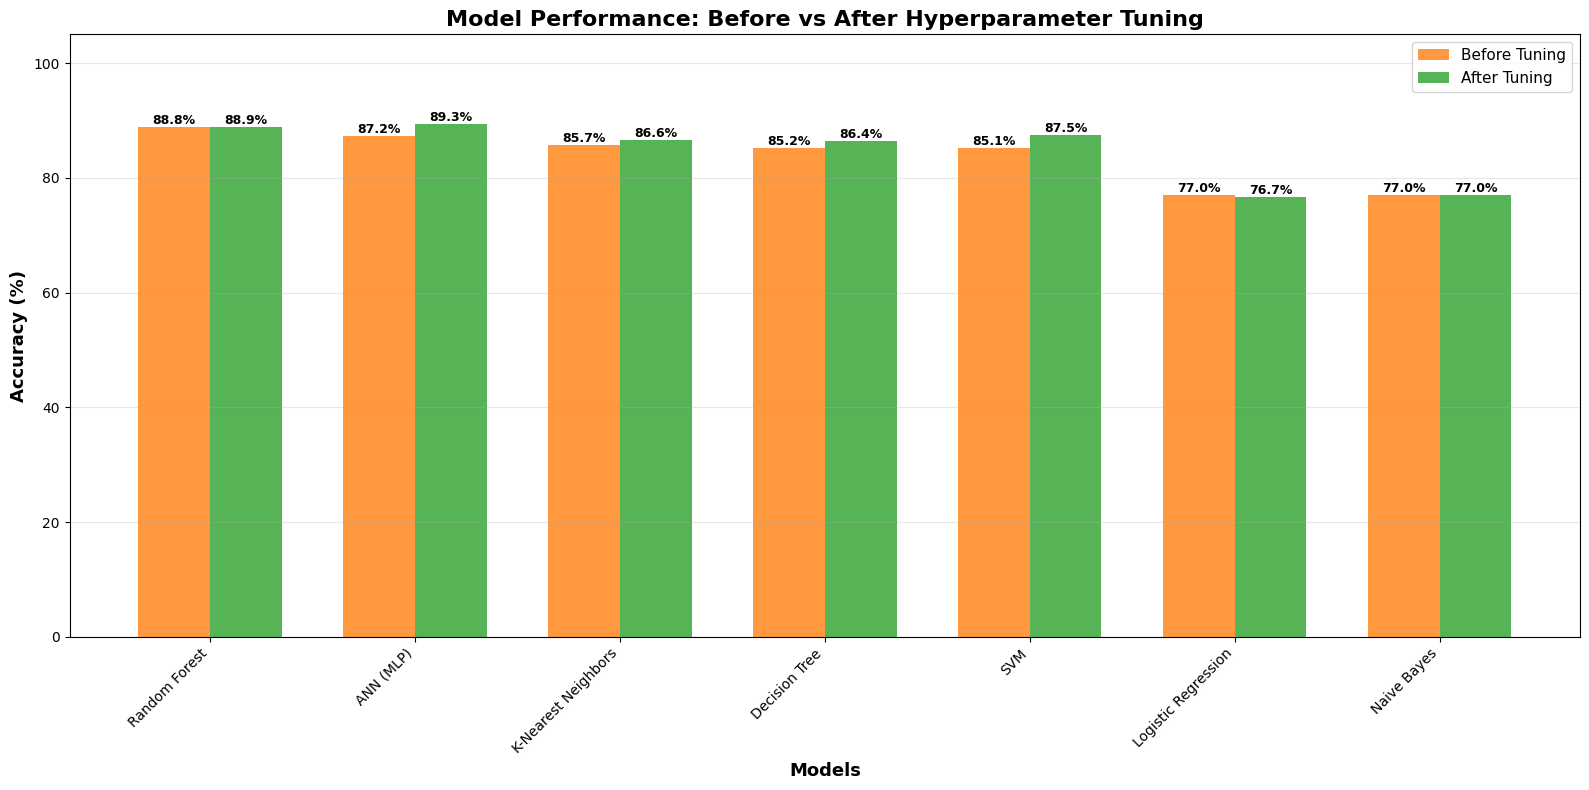

✅ Tuned model comparison saved as 'tuned_model_comparison.png'



In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

# --- CONFIGURATION ---
CSV_INPUT = "reduced_features.csv"
TEST_SIZE = 0.3
RANDOM_STATE = 42
CV_FOLDS = 5
# ---------------------

def train_all_models_with_tuning():
    print("📊 Loading reduced features dataset...")
    df = pd.read_csv(CSV_INPUT)
    
    X = df.drop('Class', axis=1)
    y = df['Class']
    
    print(f"✅ Dataset loaded: {len(df)} samples")
    print(f"   Features: {X.shape[1]}")
    print(f"   Classes: {y.unique()}")
    print(f"   Class distribution:\n{y.value_counts()}\n")
    
    print(f"📂 Splitting dataset ({int((1-TEST_SIZE)*100)}/{int(TEST_SIZE*100)})...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )
    
    print(f"   Training samples: {len(X_train)}")
    print(f"   Testing samples: {len(X_test)}\n")
    
    print("⚖️  Scaling features...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Define models with parameter grids for GridSearchCV
    models_params = {
        'Logistic Regression': {
            'model': LogisticRegression(random_state=RANDOM_STATE, max_iter=2000),
            'params': {
                'C': [0.001, 0.01, 0.1, 1, 10, 100],
                'penalty': ['l2'],
                'solver': ['lbfgs', 'liblinear', 'saga']
            }
        },
        'Decision Tree': {
            'model': DecisionTreeClassifier(random_state=RANDOM_STATE),
            'params': {
                'max_depth': [5, 10, 15, 20, 25, None],
                'min_samples_split': [2, 5, 10, 15],
                'min_samples_leaf': [1, 2, 4, 6],
                'criterion': ['gini', 'entropy']
            }
        },
        'Random Forest': {
            'model': RandomForestClassifier(random_state=RANDOM_STATE),
            'params': {
                'n_estimators': [50, 100, 200, 300],
                'max_depth': [10, 20, 30, None],
                'min_samples_split': [2, 5, 10],
                'min_samples_leaf': [1, 2, 4],
                'max_features': ['sqrt', 'log2', None]
            }
        },
        'SVM': {
            'model': SVC(random_state=RANDOM_STATE),
            'params': {
                'C': [0.1, 1, 10, 100],
                'kernel': ['linear', 'rbf', 'poly'],
                'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
                'degree': [2, 3, 4]
            }
        },
        'Naive Bayes': {
            'model': GaussianNB(),
            'params': {
                'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
            }
        },
        'K-Nearest Neighbors': {
            'model': KNeighborsClassifier(),
            'params': {
                'n_neighbors': [3, 5, 7, 9, 11, 15],
                'weights': ['uniform', 'distance'],
                'metric': ['euclidean', 'manhattan', 'minkowski'],
                'p': [1, 2]
            }
        },
        'ANN (MLP)': {
            'model': MLPClassifier(random_state=RANDOM_STATE, max_iter=2000),
            'params': {
                'hidden_layer_sizes': [(50,), (100,), (150,), (100, 50), (150, 100), (200, 100), (150, 100, 50), (200, 150, 100)],
                'activation': ['relu', 'tanh', 'logistic'],
                'solver': ['adam', 'sgd'],
                'alpha': [0.0001, 0.001, 0.01],
                'learning_rate': ['constant', 'adaptive'],
                'learning_rate_init': [0.001, 0.01, 0.1]
            }
        }
    }
    
    results_before = []
    results_after = []
    all_predictions = {}
    all_confusion_matrices = {}
    best_models = {}
    cv_scores = {}
    
    print("=" * 70)
    print("🤖 TRAINING ALL MODELS WITH GRID SEARCH + 5-FOLD CROSS VALIDATION")
    print("=" * 70)
    
    for model_name, config in models_params.items():
        print(f"\n{'='*70}")
        print(f"🔄 Training {model_name}...")
        print(f"{'='*70}")
        
        # Train baseline model first
        print("   📌 Training baseline model...")
        baseline_model = config['model']
        baseline_model.fit(X_train_scaled, y_train)
        y_pred_baseline = baseline_model.predict(X_test_scaled)
        baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
        
        results_before.append({
            'Model': model_name,
            'Accuracy (%)': baseline_accuracy * 100
        })
        
        print(f"   ✅ Baseline Accuracy: {baseline_accuracy*100:.2f}%")
        
        # Grid Search with Cross-Validation
        print(f"   🔍 Performing Grid Search with {CV_FOLDS}-Fold Cross Validation...")
        print(f"   Parameters to test: {len(list(config['params'].keys()))} parameters")
        
        grid_search = GridSearchCV(
            estimator=config['model'],
            param_grid=config['params'],
            cv=CV_FOLDS,
            scoring='accuracy',
            n_jobs=-1,
            verbose=0
        )
        
        grid_search.fit(X_train_scaled, y_train)
        
        print(f"   ✅ Best parameters found:")
        for param, value in grid_search.best_params_.items():
            print(f"      - {param}: {value}")
        
        # Best model predictions
        best_model = grid_search.best_estimator_
        y_pred = best_model.predict(X_test_scaled)
        
        # Cross-validation scores
        cv_scores_array = cross_val_score(best_model, X_train_scaled, y_train, cv=CV_FOLDS, scoring='accuracy')
        cv_scores[model_name] = cv_scores_array
        
        print(f"   📊 Cross-Validation Scores: {cv_scores_array}")
        print(f"   📊 Mean CV Score: {cv_scores_array.mean()*100:.2f}% (±{cv_scores_array.std()*100:.2f}%)")
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        
        # Store results
        results_after.append({
            'Model': model_name,
            'Accuracy (%)': accuracy * 100,
            'Precision (%)': precision * 100,
            'Recall (%)': recall * 100,
            'F1-Score (%)': f1 * 100,
            'CV Mean (%)': cv_scores_array.mean() * 100,
            'CV Std (%)': cv_scores_array.std() * 100
        })
        
        all_predictions[model_name] = y_pred
        all_confusion_matrices[model_name] = cm
        best_models[model_name] = best_model
        
        improvement = accuracy - baseline_accuracy
        print(f"   🎯 Tuned Test Accuracy: {accuracy*100:.2f}%")
        print(f"   📈 Improvement: {improvement*100:+.2f}%")
        
        # Save best model
        model_filename = f"{model_name.replace(' ', '_').replace('(', '').replace(')', '').lower()}_tuned_model.pkl"
        with open(model_filename, 'wb') as f:
            pickle.dump(best_model, f)
    
    # Save scaler
    with open('scaler_tuned.pkl', 'wb') as f:
        pickle.dump(scaler, f)
    
    print("\n" + "=" * 70)
    print("📊 MODEL COMPARISON - BEFORE VS AFTER TUNING")
    print("=" * 70)
    
    results_before_df = pd.DataFrame(results_before).sort_values('Accuracy (%)', ascending=False)
    results_after_df = pd.DataFrame(results_after).sort_values('Accuracy (%)', ascending=False)
    
    comparison_df = pd.merge(
        results_before_df, 
        results_after_df[['Model', 'Accuracy (%)', 'CV Mean (%)', 'CV Std (%)']],
        on='Model',
        suffixes=('_Before', '_After')
    )
    comparison_df['Improvement (%)'] = comparison_df['Accuracy (%)_After'] - comparison_df['Accuracy (%)_Before']
    
    print(comparison_df.to_string(index=False))
    print()
    
    # Save results
    results_after_df.to_csv('model_comparison_tuned.csv', index=False)
    comparison_df.to_csv('before_after_comparison.csv', index=False)
    
    # Visualization 1: Before vs After Comparison
    fig1, ax1 = plt.subplots(figsize=(16, 8))
    
    x = np.arange(len(comparison_df))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, comparison_df['Accuracy (%)_Before'], width, 
                    label='Before Tuning', color='#ff7f0e', alpha=0.8)
    bars2 = ax1.bar(x + width/2, comparison_df['Accuracy (%)_After'], width, 
                    label='After Tuning', color='#2ca02c', alpha=0.8)
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax1.set_xlabel('Models', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Accuracy (%)', fontsize=13, fontweight='bold')
    ax1.set_title('Model Performance: Before vs After Hyperparameter Tuning', 
                  fontsize=16, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
    ax1.legend(fontsize=11)
    ax1.grid(axis='y', alpha=0.3)
    ax1.set_ylim([0, 105])
    
    plt.tight_layout()
    plt.savefig('before_after_comparison.png', dpi=300, bbox_inches='tight')
    print("✅ Before/After comparison saved as 'before_after_comparison.png'\n")
    plt.show()
    
    # Visualization 2: All Metrics Comparison (After Tuning)
    fig2, ax2 = plt.subplots(figsize=(16, 8))
    
    x = np.arange(len(results_after_df))
    width = 0.2
    
    ax2.bar(x - 1.5*width, results_after_df['Accuracy (%)'], width, label='Accuracy', color='#1f77b4')
    ax2.bar(x - 0.5*width, results_after_df['Precision (%)'], width, label='Precision', color='#ff7f0e')
    ax2.bar(x + 0.5*width, results_after_df['Recall (%)'], width, label='Recall', color='#2ca02c')
    ax2.bar(x + 1.5*width, results_after_df['F1-Score (%)'], width, label='F1-Score', color='#d62728')
    
    ax2.set_xlabel('Models', fontsize=13, fontweight='bold')
    ax2.set_ylabel('Score (%)', fontsize=13, fontweight='bold')
    ax2.set_title('Tuned Model Performance - All Metrics Comparison', fontsize=16, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(results_after_df['Model'], rotation=45, ha='right')
    ax2.legend(fontsize=11)
    ax2.grid(axis='y', alpha=0.3)
    ax2.set_ylim([0, 105])
    
    plt.tight_layout()
    plt.savefig('tuned_model_comparison.png', dpi=300, bbox_inches='tight')
    print("✅ Tuned model comparison saved as 'tuned_model_comparison.png'\n")
    plt.show()
    
    # Visualization 3: Cross-Validation Scores
    fig3, ax3 = plt.subplots(figsize=(14, 8))
    
    cv_data = []
    model_names = []
    for model_name, scores in cv_scores.items():
        cv_data.extend(scores * 100)
        model_names.extend([model_name] * len(scores))
    
    cv_df = pd.DataFrame({'Model': model_names, 'CV Score (%)': cv_data})
    
    box_plot = ax3.boxplot([cv_scores[model]*100 for model in results_after_df['Model']], 
                           labels=results_after_df['Model'],
                           patch_artist=True,
                           showmeans=True)
    
    colors = plt.cm.Set3(np.linspace(0, 1, len(results_after_df)))
    for patch, color in zip(box_plot['boxes'], colors):
        patch.set_facecolor(color)
    
    ax3.set_xlabel('Models', fontsize=13, fontweight='bold')
    ax3.set_ylabel('Cross-Validation Score (%)', fontsize=13, fontweight='bold')
    ax3.set_title(f'{CV_FOLDS}-Fold Cross-Validation Scores Distribution', fontsize=16, fontweight='bold')
    ax3.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.savefig('cross_validation_scores.png', dpi=300, bbox_inches='tight')
    print("✅ Cross-validation scores saved as 'cross_validation_scores.png'\n")
    plt.show()
    
    # Visualization 4: All Confusion Matrices
    class_names = ['Over-Dried', 'Perfectly-Dried', 'Under-Dried']
    n_models = len(all_confusion_matrices)
    cols = 3
    rows = (n_models + cols - 1) // cols
    
    fig4, axes = plt.subplots(rows, cols, figsize=(18, rows*5))
    axes = axes.flatten()
    
    for idx, (model_name, cm) in enumerate(all_confusion_matrices.items()):
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=class_names, yticklabels=class_names,
                    cbar_kws={"shrink": 0.8}, ax=axes[idx])
        
        accuracy = results_after_df[results_after_df['Model'] == model_name]['Accuracy (%)'].values[0]
        axes[idx].set_title(f'{model_name}\nAccuracy: {accuracy:.2f}%', 
                           fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('Actual')
        axes[idx].set_xlabel('Predicted')
    
    for idx in range(n_models, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig('all_confusion_matrices_tuned.png', dpi=300, bbox_inches='tight')
    print("✅ All confusion matrices saved as 'all_confusion_matrices_tuned.png'\n")
    plt.show()
    
    # Per-Class Performance
    print("=" * 70)
    print("📊 PER-CLASS PERFORMANCE (AFTER TUNING)")
    print("=" * 70)
    
    per_class_results = []
    
    for model_name in results_after_df['Model']:
        y_pred = all_predictions[model_name]
        cm = all_confusion_matrices[model_name]
        
        precision_per_class = precision_score(y_test, y_pred, average=None)
        recall_per_class = recall_score(y_test, y_pred, average=None)
        f1_per_class = f1_score(y_test, y_pred, average=None)
        
        for i, class_name in enumerate(class_names):
            class_accuracy = (cm[i, i] / cm[i].sum()) * 100
            per_class_results.append({
                'Model': model_name,
                'Class': class_name,
                'Accuracy (%)': f"{class_accuracy:.2f}",
                'Precision': f"{precision_per_class[i]:.4f}",
                'Recall': f"{recall_per_class[i]:.4f}",
                'F1-Score': f"{f1_per_class[i]:.4f}"
            })
    
    per_class_df = pd.DataFrame(per_class_results)
    per_class_df.to_csv('per_class_performance_tuned.csv', index=False)
    print(per_class_df.to_string(index=False))
    print()
    
    # Find best model
    best_model_name = results_after_df.iloc[0]['Model']
    best_accuracy = results_after_df.iloc[0]['Accuracy (%)']
    best_cv_mean = results_after_df.iloc[0]['CV Mean (%)']
    
    print("=" * 70)
    print("🏆 BEST MODEL AFTER TUNING")
    print("=" * 70)
    print(f"   Model: {best_model_name}")
    print(f"   Test Accuracy: {best_accuracy:.2f}%")
    print(f"   Cross-Validation Mean: {best_cv_mean:.2f}%")
    print("=" * 70)
    
    print("\n📁 OUTPUT FILES GENERATED:")
    print("   1. model_comparison_tuned.csv - Tuned model performance")
    print("   2. before_after_comparison.csv - Comparison table")
    print("   3. per_class_performance_tuned.csv - Per-class metrics")
    print("   4. before_after_comparison.png - Before/After chart")
    print("   5. tuned_model_comparison.png - All metrics comparison")
    print("   6. cross_validation_scores.png - CV scores distribution")
    print("   7. all_confusion_matrices_tuned.png - All confusion matrices")
    print("   8. scaler_tuned.pkl - Feature scaler")
    print("   9. [model_name]_tuned_model.pkl - Tuned models (7 files)")
    print("=" * 70)
    
    return best_models, results_after_df, per_class_df, comparison_df

if __name__ == "__main__":
    models, results, per_class, comparison = train_all_models_with_tuning()

📊 Loading reduced features dataset...
✅ Dataset loaded: 15206 samples
   Features: 5
   Classes: [0 1 2]
   Class distribution:
Class
1    8028
0    3808
2    3370
Name: count, dtype: int64

📂 Splitting dataset (70/30)...
   Training samples: 10644
   Testing samples: 4562

⚖️  Scaling features...
🧠 INTENSIVE ANN (MLP) HYPERPARAMETER TUNING
🎯 Target: 95%+ Accuracy

📋 Parameter combinations to test:
   - hidden_layer_sizes: 27 architectures
   - activation: 3 functions

   💡 Total combinations: 81
   ⏱️  Estimated time: ~202-405 seconds

📌 Training baseline ANN model...
   ✅ Baseline Accuracy: 87.24%

🔍 Performing Grid Search with 5-Fold Cross Validation...
   (Testing different neural network architectures)

Fitting 5 folds for each of 81 candidates, totalling 405 fits

✅ GRID SEARCH COMPLETED!

🏆 BEST PARAMETERS FOUND:
----------------------------------------------------------------------
   hidden_layer_sizes: (350, 250, 200, 100)
   activation: relu
---------------------------------

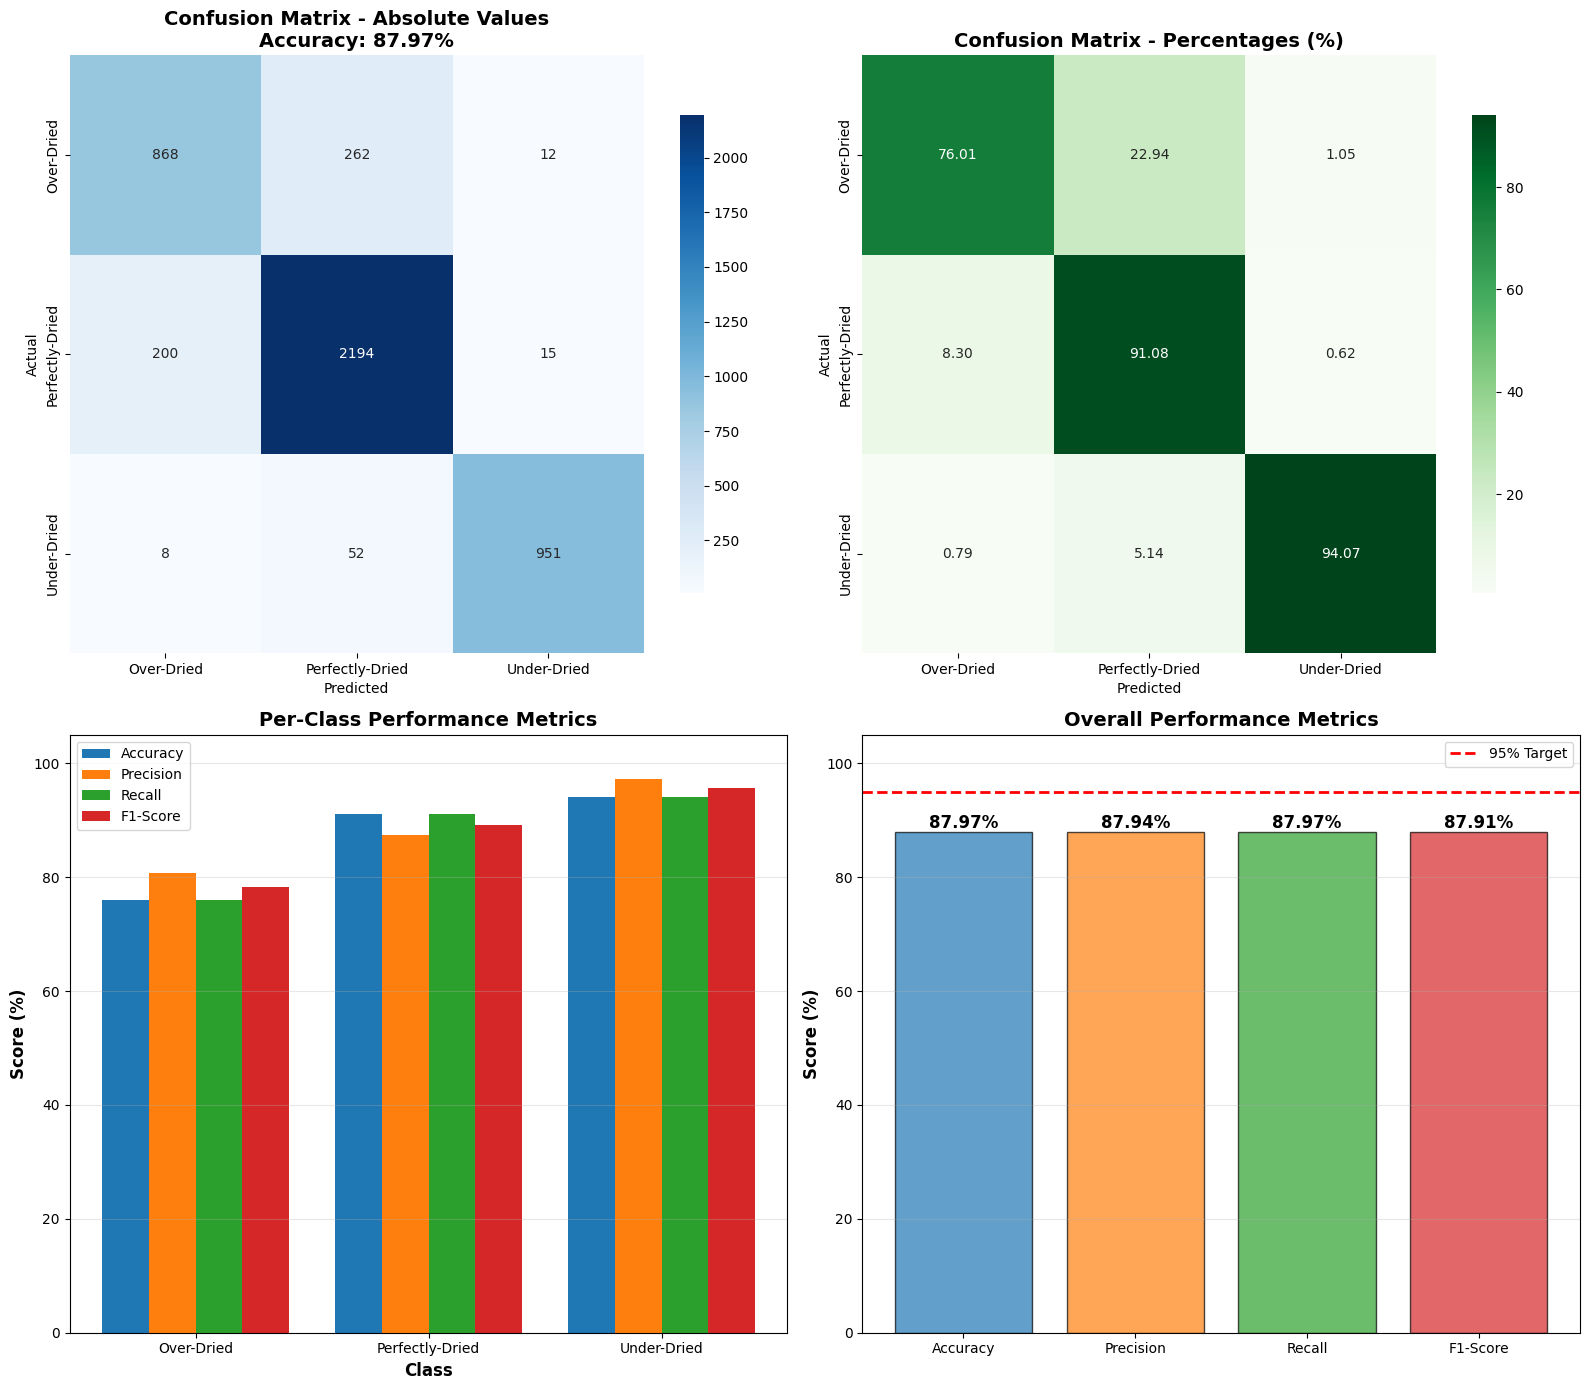

✅ Cross-validation visualization saved as 'ann_cross_validation_scores.png'



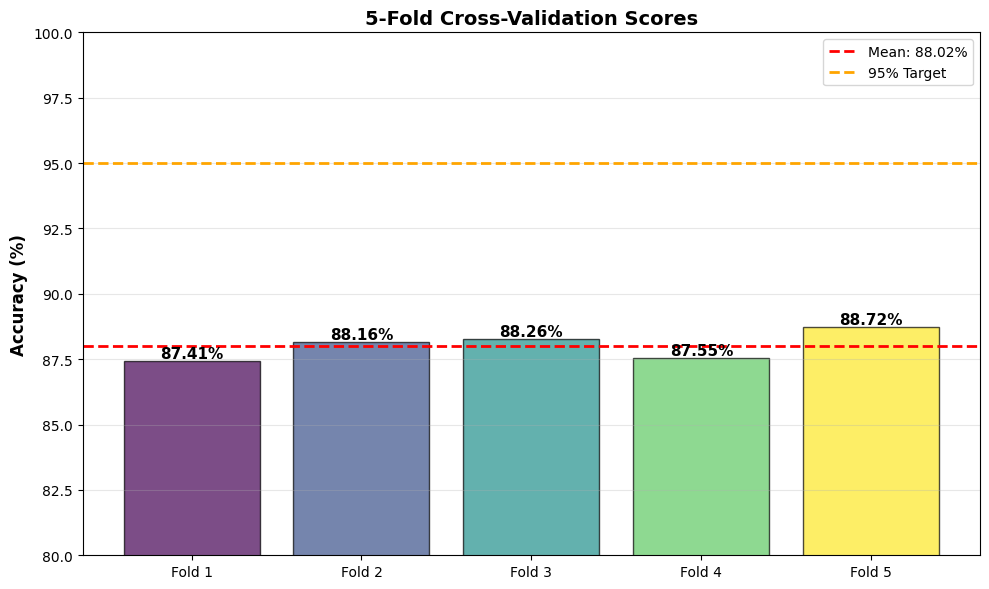

✅ Before/After comparison saved as 'ann_before_after_comparison.png'



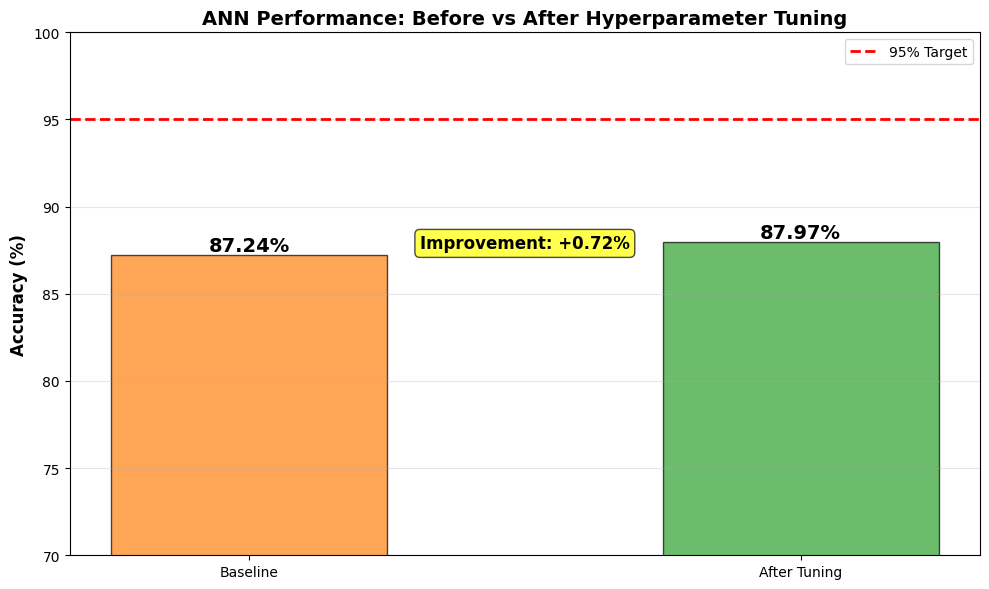

💾 Saving tuned ANN model and scaler...
✅ Grid search results saved as 'ann_grid_search_results.csv'

🎉 ANN HYPERPARAMETER TUNING COMPLETE!
📊 Current accuracy: 87.97%
📊 Gap to 95% target: 7.03%

💡 Suggestions for further improvement:
   - Collect more training data
   - Try feature engineering
   - Experiment with ensemble methods
   - Consider data augmentation techniques

📁 ALL OUTPUT FILES:
   1. ann_performance_matrix.csv - Per-class performance
   2. ann_metrics_summary.csv - Overall metrics summary
   3. ann_comprehensive_performance.png - All visualizations
   4. ann_cross_validation_scores.png - CV scores
   5. ann_before_after_comparison.png - Improvement chart
   6. ann_best_model.pkl - Tuned ANN model
   7. ann_scaler.pkl - Feature scaler
   8. ann_grid_search_results.csv - Detailed grid search results


In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

# --- CONFIGURATION ---
CSV_INPUT = "reduced_features.csv"
TEST_SIZE = 0.3
RANDOM_STATE = 42
CV_FOLDS = 5
# ---------------------

def intensive_ann_tuning():
    print("📊 Loading reduced features dataset...")
    df = pd.read_csv(CSV_INPUT)
    
    X = df.drop('Class', axis=1)
    y = df['Class']
    
    print(f"✅ Dataset loaded: {len(df)} samples")
    print(f"   Features: {X.shape[1]}")
    print(f"   Classes: {y.unique()}")
    print(f"   Class distribution:\n{y.value_counts()}\n")
    
    print(f"📂 Splitting dataset ({int((1-TEST_SIZE)*100)}/{int(TEST_SIZE*100)})...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )
    
    print(f"   Training samples: {len(X_train)}")
    print(f"   Testing samples: {len(X_test)}\n")
    
    print("⚖️  Scaling features...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print("=" * 70)
    print("🧠 INTENSIVE ANN (MLP) HYPERPARAMETER TUNING")
    print("=" * 70)
    print("🎯 Target: 95%+ Accuracy\n")
    
    # Focused parameter grid - Hidden Layers and Activation only
    param_grid = {
        'hidden_layer_sizes': [
            (50,), (100,), (150,), (200,), (250,), (300,), (350,), (400,),
            (100, 50), (150, 75), (200, 100), (250, 125), (300, 150), (350, 175), (400, 200),
            (150, 100, 50), (200, 150, 100), (250, 200, 100), (300, 200, 150), (350, 250, 150), (400, 300, 200),
            (200, 150, 100, 50), (300, 200, 150, 100), (350, 250, 200, 100), (400, 300, 200, 100),
            (300, 250, 200, 150, 100), (400, 350, 300, 250, 200)
        ],
        'activation': ['relu', 'tanh', 'logistic']
    }
    
    print(f"📋 Parameter combinations to test:")
    print(f"   - hidden_layer_sizes: {len(param_grid['hidden_layer_sizes'])} architectures")
    print(f"   - activation: {len(param_grid['activation'])} functions")
    total_combinations = len(param_grid['hidden_layer_sizes']) * len(param_grid['activation'])
    print(f"\n   💡 Total combinations: {total_combinations}")
    print(f"   ⏱️  Estimated time: ~{total_combinations * CV_FOLDS * 0.5:.0f}-{total_combinations * CV_FOLDS:.0f} seconds\n")
    
    # Baseline model
    print("📌 Training baseline ANN model...")
    baseline_model = MLPClassifier(random_state=RANDOM_STATE, max_iter=2000)
    baseline_model.fit(X_train_scaled, y_train)
    y_pred_baseline = baseline_model.predict(X_test_scaled)
    baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
    print(f"   ✅ Baseline Accuracy: {baseline_accuracy*100:.2f}%\n")
    
    # Grid Search
    print("🔍 Performing Grid Search with 5-Fold Cross Validation...")
    print("   (Testing different neural network architectures)\n")
    
    ann_model = MLPClassifier(
        random_state=RANDOM_STATE,
        max_iter=2000,
        alpha=0.01,
        learning_rate='adaptive',
        learning_rate_init=0.01,
        solver='adam'
    )
    
    grid_search = GridSearchCV(
        estimator=ann_model,
        param_grid=param_grid,
        cv=CV_FOLDS,
        scoring='accuracy',
        n_jobs=-1,
        verbose=2,
        return_train_score=True
    )
    
    grid_search.fit(X_train_scaled, y_train)
    
    print("\n" + "=" * 70)
    print("✅ GRID SEARCH COMPLETED!")
    print("=" * 70)
    
    # Best parameters
    print("\n🏆 BEST PARAMETERS FOUND:")
    print("-" * 70)
    print(f"   hidden_layer_sizes: {grid_search.best_params_['hidden_layer_sizes']}")
    print(f"   activation: {grid_search.best_params_['activation']}")
    print("-" * 70)
    
    # Best model evaluation
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test_scaled)
    
    # Cross-validation scores
    cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=CV_FOLDS, scoring='accuracy')
    
    print(f"\n📊 CROSS-VALIDATION RESULTS:")
    print(f"   Fold scores: {[f'{score*100:.2f}%' for score in cv_scores]}")
    print(f"   Mean CV Score: {cv_scores.mean()*100:.2f}%")
    print(f"   Std CV Score: ±{cv_scores.std()*100:.2f}%")
    
    # Calculate all metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Per-class metrics
    precision_per_class = precision_score(y_test, y_pred, average=None)
    recall_per_class = recall_score(y_test, y_pred, average=None)
    f1_per_class = f1_score(y_test, y_pred, average=None)
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    print("\n" + "=" * 70)
    print("📈 OVERALL PERFORMANCE METRICS")
    print("=" * 70)
    print(f"Test Accuracy:      {accuracy*100:.2f}%")
    print(f"Precision:          {precision*100:.2f}%")
    print(f"Recall:             {recall*100:.2f}%")
    print(f"F1-Score:           {f1*100:.2f}%")
    print(f"Improvement:        {(accuracy - baseline_accuracy)*100:+.2f}%")
    print("=" * 70)
    
    # Classification report
    class_names = ['Over-Dried (0)', 'Perfectly-Dried (1)', 'Under-Dried (2)']
    print("\n📋 DETAILED CLASSIFICATION REPORT:")
    print("-" * 70)
    print(classification_report(y_test, y_pred, target_names=class_names))
    
    # Confusion matrix details
    print("=" * 70)
    print("📊 CONFUSION MATRIX")
    print("=" * 70)
    print(cm)
    print()
    
    # Per-class accuracy
    print("=" * 70)
    print("📊 PER-CLASS PERFORMANCE BREAKDOWN")
    print("=" * 70)
    performance_data = []
    for i, class_name in enumerate(class_names):
        class_accuracy = (cm[i, i] / cm[i].sum()) * 100
        performance_data.append({
            'Class': class_name,
            'Accuracy (%)': f"{class_accuracy:.2f}",
            'Precision': f"{precision_per_class[i]:.4f}",
            'Recall': f"{recall_per_class[i]:.4f}",
            'F1-Score': f"{f1_per_class[i]:.4f}",
            'Support': cm[i].sum()
        })
        print(f"\n{class_name}:")
        print(f"   Accuracy:  {class_accuracy:.2f}%")
        print(f"   Precision: {precision_per_class[i]:.4f}")
        print(f"   Recall:    {recall_per_class[i]:.4f}")
        print(f"   F1-Score:  {f1_per_class[i]:.4f}")
        print(f"   Support:   {cm[i].sum()}")
    
    performance_df = pd.DataFrame(performance_data)
    performance_df.to_csv('ann_performance_matrix.csv', index=False)
    print("\n✅ Performance matrix saved as 'ann_performance_matrix.csv'")
    
    # Save comparison data
    comparison_data = {
        'Metric': ['Baseline Accuracy', 'Tuned Accuracy', 'Improvement', 
                   'Precision', 'Recall', 'F1-Score', 'CV Mean', 'CV Std'],
        'Value (%)': [
            f"{baseline_accuracy*100:.2f}",
            f"{accuracy*100:.2f}",
            f"{(accuracy - baseline_accuracy)*100:+.2f}",
            f"{precision*100:.2f}",
            f"{recall*100:.2f}",
            f"{f1*100:.2f}",
            f"{cv_scores.mean()*100:.2f}",
            f"{cv_scores.std()*100:.2f}"
        ]
    }
    comparison_df = pd.DataFrame(comparison_data)
    comparison_df.to_csv('ann_metrics_summary.csv', index=False)
    print("✅ Metrics summary saved as 'ann_metrics_summary.csv'\n")
    
    # VISUALIZATION 1: Confusion Matrix
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    
    # Confusion Matrix - Absolute Values
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Over-Dried', 'Perfectly-Dried', 'Under-Dried'],
                yticklabels=['Over-Dried', 'Perfectly-Dried', 'Under-Dried'],
                cbar_kws={"shrink": 0.8}, ax=axes[0, 0])
    axes[0, 0].set_title(f'Confusion Matrix - Absolute Values\nAccuracy: {accuracy*100:.2f}%', 
                         fontsize=14, fontweight='bold')
    axes[0, 0].set_ylabel('Actual')
    axes[0, 0].set_xlabel('Predicted')
    
    # Confusion Matrix - Percentages
    cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    sns.heatmap(cm_percentage, annot=True, fmt='.2f', cmap='Greens', 
                xticklabels=['Over-Dried', 'Perfectly-Dried', 'Under-Dried'],
                yticklabels=['Over-Dried', 'Perfectly-Dried', 'Under-Dried'],
                cbar_kws={"shrink": 0.8}, ax=axes[0, 1])
    axes[0, 1].set_title('Confusion Matrix - Percentages (%)', 
                         fontsize=14, fontweight='bold')
    axes[0, 1].set_ylabel('Actual')
    axes[0, 1].set_xlabel('Predicted')
    
    # Per-Class Metrics Bar Chart
    classes = ['Over-Dried', 'Perfectly-Dried', 'Under-Dried']
    x = np.arange(len(classes))
    width = 0.2
    
    accuracies = [(cm[i, i] / cm[i].sum()) * 100 for i in range(len(classes))]
    
    axes[1, 0].bar(x - 1.5*width, accuracies, width, label='Accuracy', color='#1f77b4')
    axes[1, 0].bar(x - 0.5*width, precision_per_class * 100, width, label='Precision', color='#ff7f0e')
    axes[1, 0].bar(x + 0.5*width, recall_per_class * 100, width, label='Recall', color='#2ca02c')
    axes[1, 0].bar(x + 1.5*width, f1_per_class * 100, width, label='F1-Score', color='#d62728')
    
    axes[1, 0].set_xlabel('Class', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Score (%)', fontsize=12, fontweight='bold')
    axes[1, 0].set_title('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(classes)
    axes[1, 0].legend()
    axes[1, 0].grid(axis='y', alpha=0.3)
    axes[1, 0].set_ylim([0, 105])
    
    # Overall Metrics
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    bars = axes[1, 1].bar(metrics, values, color=colors, alpha=0.7, edgecolor='black')
    
    for bar in bars:
        height = bar.get_height()
        axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}%',
                ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    axes[1, 1].set_ylabel('Score (%)', fontsize=12, fontweight='bold')
    axes[1, 1].set_title('Overall Performance Metrics', fontsize=14, fontweight='bold')
    axes[1, 1].set_ylim([0, 105])
    axes[1, 1].grid(axis='y', alpha=0.3)
    
    # Add 95% target line
    axes[1, 1].axhline(y=95, color='red', linestyle='--', linewidth=2, label='95% Target')
    axes[1, 1].legend()
    
    plt.tight_layout()
    plt.savefig('ann_comprehensive_performance.png', dpi=300, bbox_inches='tight')
    print("✅ Comprehensive performance visualization saved as 'ann_comprehensive_performance.png'\n")
    plt.show()
    
    # VISUALIZATION 2: Cross-Validation Scores
    fig2, ax2 = plt.subplots(figsize=(10, 6))
    
    folds = [f'Fold {i+1}' for i in range(CV_FOLDS)]
    colors_cv = plt.cm.viridis(np.linspace(0, 1, CV_FOLDS))
    
    bars = ax2.bar(folds, cv_scores * 100, color=colors_cv, alpha=0.7, edgecolor='black')
    ax2.axhline(y=cv_scores.mean() * 100, color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {cv_scores.mean()*100:.2f}%')
    ax2.axhline(y=95, color='orange', linestyle='--', linewidth=2, label='95% Target')
    
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}%',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    ax2.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
    ax2.set_title('5-Fold Cross-Validation Scores', fontsize=14, fontweight='bold')
    ax2.set_ylim([80, 100])
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('ann_cross_validation_scores.png', dpi=300, bbox_inches='tight')
    print("✅ Cross-validation visualization saved as 'ann_cross_validation_scores.png'\n")
    plt.show()
    
    # VISUALIZATION 3: Before vs After Comparison
    fig3, ax3 = plt.subplots(figsize=(10, 6))
    
    comparison_metrics = ['Baseline', 'After Tuning']
    comparison_values = [baseline_accuracy * 100, accuracy * 100]
    colors_comp = ['#ff7f0e', '#2ca02c']
    
    bars = ax3.bar(comparison_metrics, comparison_values, color=colors_comp, alpha=0.7, 
                   edgecolor='black', width=0.5)
    ax3.axhline(y=95, color='red', linestyle='--', linewidth=2, label='95% Target')
    
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}%',
                ha='center', va='bottom', fontsize=14, fontweight='bold')
    
    improvement = accuracy - baseline_accuracy
    ax3.text(0.5, (baseline_accuracy + accuracy) * 50,
            f'Improvement: {improvement*100:+.2f}%',
            ha='center', fontsize=12, fontweight='bold', 
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
    
    ax3.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
    ax3.set_title('ANN Performance: Before vs After Hyperparameter Tuning', 
                  fontsize=14, fontweight='bold')
    ax3.set_ylim([70, 100])
    ax3.legend()
    ax3.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('ann_before_after_comparison.png', dpi=300, bbox_inches='tight')
    print("✅ Before/After comparison saved as 'ann_before_after_comparison.png'\n")
    plt.show()
    
    # Save model and scaler
    print("💾 Saving tuned ANN model and scaler...")
    with open('ann_best_model.pkl', 'wb') as f:
        pickle.dump(best_model, f)
    with open('ann_scaler.pkl', 'wb') as f:
        pickle.dump(scaler, f)
    
    # Save Grid Search results for analysis
    cv_results_df = pd.DataFrame(grid_search.cv_results_)
    cv_results_df = cv_results_df.sort_values('rank_test_score')
    cv_results_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].to_csv(
        'ann_grid_search_results.csv', index=False
    )
    print("✅ Grid search results saved as 'ann_grid_search_results.csv'")
    
    print("\n" + "=" * 70)
    print("🎉 ANN HYPERPARAMETER TUNING COMPLETE!")
    print("=" * 70)
    
    if accuracy >= 0.95:
        print("🎊 SUCCESS! Target of 95%+ accuracy achieved!")
    else:
        print(f"📊 Current accuracy: {accuracy*100:.2f}%")
        print(f"📊 Gap to 95% target: {(0.95 - accuracy)*100:.2f}%")
        print("\n💡 Suggestions for further improvement:")
        print("   - Collect more training data")
        print("   - Try feature engineering")
        print("   - Experiment with ensemble methods")
        print("   - Consider data augmentation techniques")
    
    print("\n📁 ALL OUTPUT FILES:")
    print("   1. ann_performance_matrix.csv - Per-class performance")
    print("   2. ann_metrics_summary.csv - Overall metrics summary")
    print("   3. ann_comprehensive_performance.png - All visualizations")
    print("   4. ann_cross_validation_scores.png - CV scores")
    print("   5. ann_before_after_comparison.png - Improvement chart")
    print("   6. ann_best_model.pkl - Tuned ANN model")
    print("   7. ann_scaler.pkl - Feature scaler")
    print("   8. ann_grid_search_results.csv - Detailed grid search results")
    print("=" * 70)
    
    return best_model, scaler, accuracy, performance_df, grid_search

if __name__ == "__main__":
    model, scaler, acc, perf_df, grid = intensive_ann_tuning()

In [8]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


📊 Loading reduced features dataset...
✅ Dataset loaded: 15206 samples
   Features: 5

📊 ORIGINAL Class distribution:
Class
0    3808
1    8028
2    3370
Name: count, dtype: int64

🔄 APPLYING SMOTE TO FULL DATASET (Before Split)
   Target: Match ALL classes to Class 1 count (8028)
✅ SMOTE applied successfully!
   Total samples: 15206 → 24084

📊 NEW Class distribution (Balanced):
Class
0    8028
1    8028
2    8028
Name: count, dtype: int64
   Class 0: 3808 → 8028 samples
   Class 1: 8028 → 8028 samples
   Class 2: 3370 → 8028 samples

⚠️  NOTE: Data is now perfectly balanced at 8,028 samples per class.

📂 Splitting dataset (70/30)...
   Training samples: 16858
   Testing samples:  7226

⚖️  Scaling features...

🧠 INTENSIVE ANN (MLP) HYPERPARAMETER TUNING
🎯 Target: 95%+ Accuracy

📋 Parameter combinations to test:
   - hidden_layer_sizes: 27 architectures
   - activation: 3 functions

   💡 Total combinations: 81
   ⏱️  Estimated time: ~202-405 seconds

   ℹ️  Baseline Accuracy (Random Gue

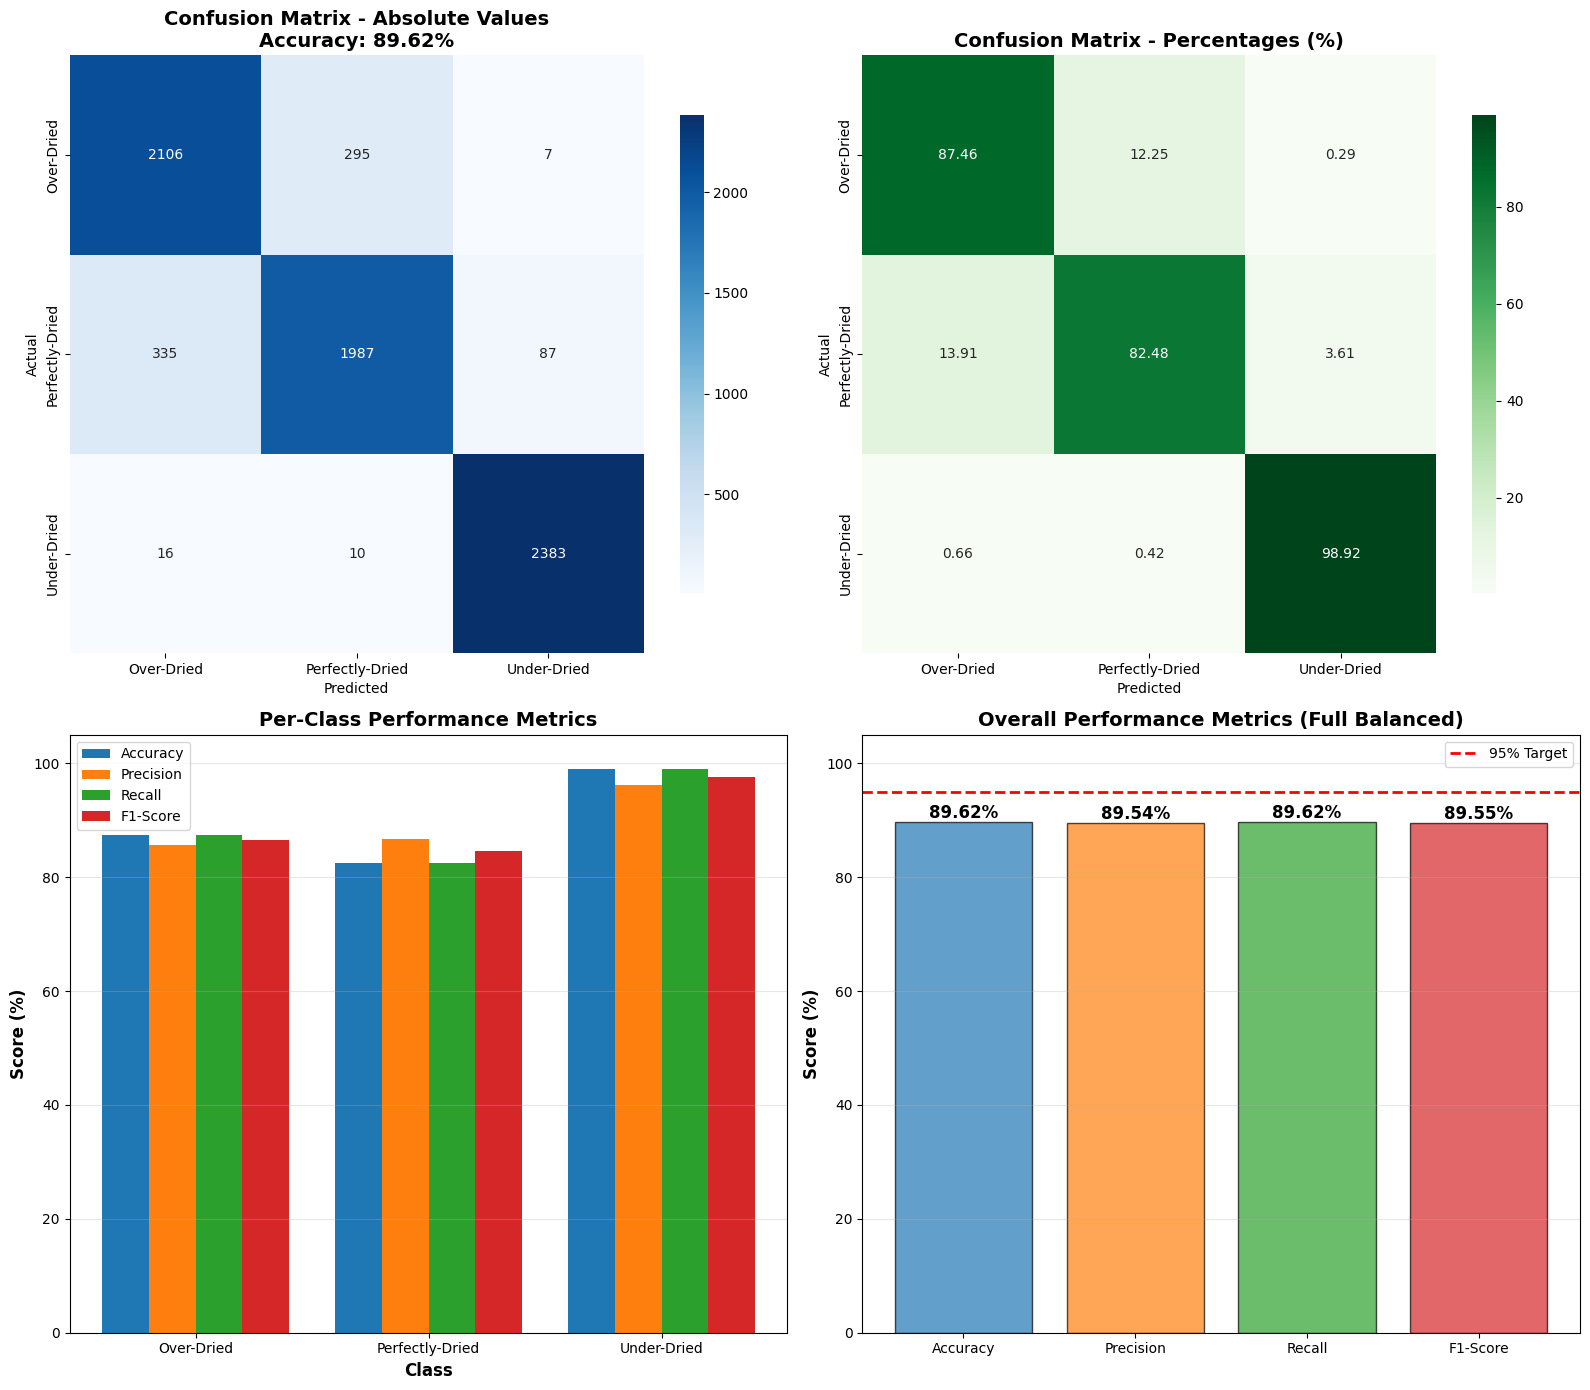

✅ SMOTE class distribution saved as 'smote_class_distribution.png'



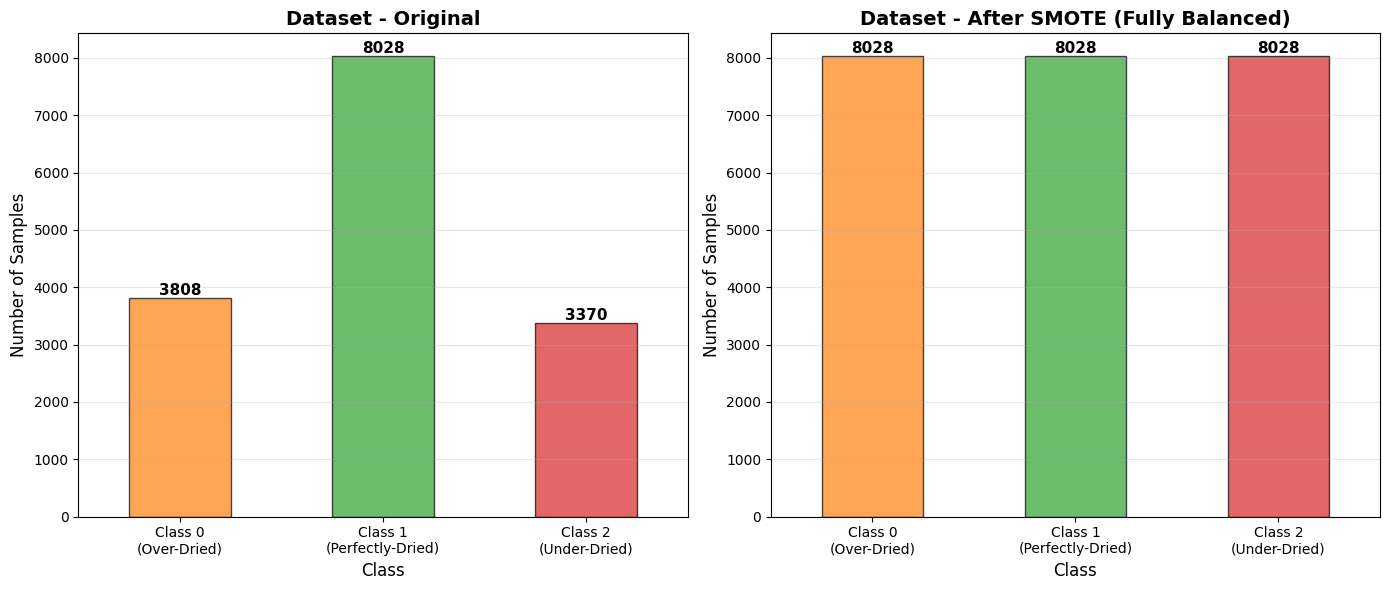

✅ Cross-validation visualization saved as 'ann_smote_cross_validation_scores.png'



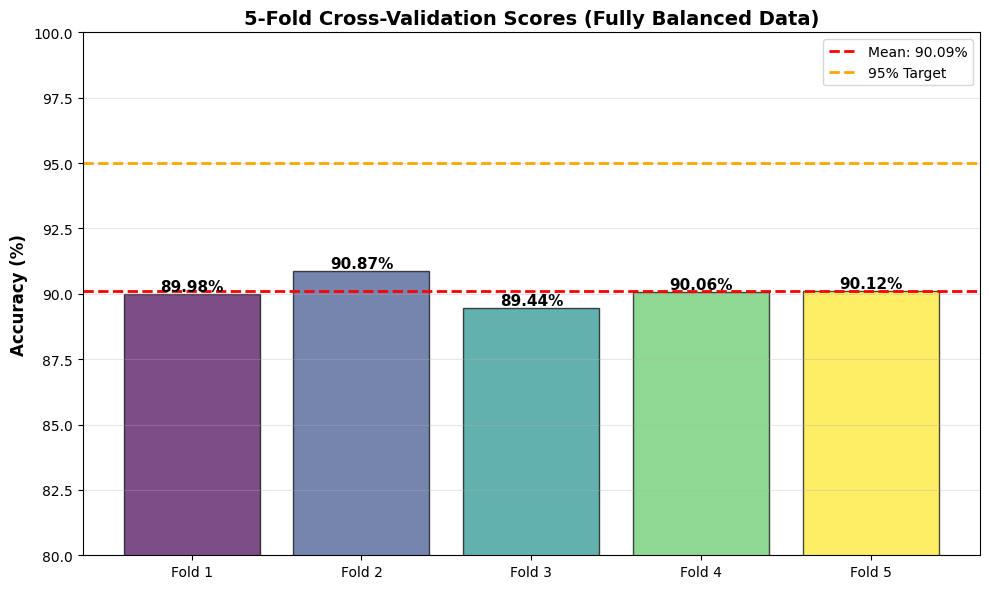

💾 Saving tuned ANN model and scaler...
✅ Grid search results saved as 'ann_smote_grid_search_results.csv'

🎉 ANN HYPERPARAMETER TUNING COMPLETE!
📊 Current accuracy: 89.62%
📊 Gap to 95% target: 5.38%

📁 ALL OUTPUT FILES:
   1. ann_smote_performance_matrix.csv - Per-class performance
   2. ann_smote_metrics_summary.csv - Overall metrics summary
   3. ann_smote_comprehensive_performance.png - All visualizations
   4. smote_class_distribution.png - Before/After SMOTE distribution
   5. ann_smote_cross_validation_scores.png - CV scores
   6. ann_smote_best_model.pkl - Tuned ANN model
   7. ann_smote_scaler.pkl - Feature scaler
   8. ann_smote_grid_search_results.csv - Detailed grid search results


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

# --- CONFIGURATION ---
CSV_INPUT = "reduced_features.csv"
TEST_SIZE = 0.3
RANDOM_STATE = 42
CV_FOLDS = 5
# ---------------------

def intensive_ann_tuning_full_smote():
    print("📊 Loading reduced features dataset...")
    df = pd.read_csv(CSV_INPUT)
    
    X = df.drop('Class', axis=1)
    y = df['Class']
    
    print(f"✅ Dataset loaded: {len(df)} samples")
    print(f"   Features: {X.shape[1]}")
    print("\n📊 ORIGINAL Class distribution:")
    original_counts = y.value_counts().sort_index()
    print(original_counts)
    
    # --- SMOTE APPLIED BEFORE SPLIT ---
    print("\n" + "="*50)
    print("🔄 APPLYING SMOTE TO FULL DATASET (Before Split)")
    print("   Target: Match ALL classes to Class 1 count (8028)")
    print("="*50)
    
    # We use 'all' strategy to ensure every class matches the majority count
    # Since Class 1 is 8028 (majority), Class 0 and 2 will be upsampled to 8028.
    smote = SMOTE(random_state=RANDOM_STATE, sampling_strategy='all')
    X_resampled, y_resampled = smote.fit_resample(X, y)
    
    print(f"✅ SMOTE applied successfully!")
    print(f"   Total samples: {len(X)} → {len(X_resampled)}")
    
    print("\n📊 NEW Class distribution (Balanced):")
    new_counts = pd.Series(y_resampled).value_counts().sort_index()
    print(new_counts)
    
    for cls in sorted(y.unique()):
        print(f"   Class {cls}: {original_counts[cls]} → {new_counts[cls]} samples")
    
    print("\n⚠️  NOTE: Data is now perfectly balanced at 8,028 samples per class.")
    # ----------------------------------

    print(f"\n📂 Splitting dataset ({int((1-TEST_SIZE)*100)}/{int(TEST_SIZE*100)})...")
    
    # Split the already balanced data
    X_train, X_test, y_train, y_test = train_test_split(
        X_resampled, y_resampled, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_resampled
    )
    
    print(f"   Training samples: {len(X_train)}")
    print(f"   Testing samples:  {len(X_test)}")
    
    print("\n⚖️  Scaling features...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print("\n" + "=" * 70)
    print("🧠 INTENSIVE ANN (MLP) HYPERPARAMETER TUNING")
    print("=" * 70)
    print("🎯 Target: 95%+ Accuracy\n")
    
    # Focused parameter grid
    param_grid = {
        'hidden_layer_sizes': [
            (50,), (100,), (150,), (200,), (250,), (300,), (350,), (400,),
            (100, 50), (150, 75), (200, 100), (250, 125), (300, 150), (350, 175), (400, 200),
            (150, 100, 50), (200, 150, 100), (250, 200, 100), (300, 200, 150), (350, 250, 150), (400, 300, 200),
            (200, 150, 100, 50), (300, 200, 150, 100), (350, 250, 200, 100), (400, 300, 200, 100),
            (300, 250, 200, 150, 100), (400, 350, 300, 250, 200)
        ],
        'activation': ['relu', 'tanh', 'logistic']
    }
    
    print(f"📋 Parameter combinations to test:")
    print(f"   - hidden_layer_sizes: {len(param_grid['hidden_layer_sizes'])} architectures")
    print(f"   - activation: {len(param_grid['activation'])} functions")
    total_combinations = len(param_grid['hidden_layer_sizes']) * len(param_grid['activation'])
    print(f"\n   💡 Total combinations: {total_combinations}")
    print(f"   ⏱️  Estimated time: ~{total_combinations * CV_FOLDS * 0.5:.0f}-{total_combinations * CV_FOLDS:.0f} seconds\n")
    
    # Baseline calculation (Naive baseline since data is perfectly balanced now, baseline is 33%)
    # We will skip training a separate baseline model to save time and compare against 33% random chance
    baseline_accuracy = 0.3333
    print(f"   ℹ️  Baseline Accuracy (Random Guess on Balanced Data): {baseline_accuracy*100:.2f}%\n")
    
    # Grid Search
    print("🔍 Performing Grid Search with 5-Fold Cross Validation...")
    
    ann_model = MLPClassifier(
        random_state=RANDOM_STATE,
        max_iter=2000,
        alpha=0.01,
        learning_rate='adaptive',
        learning_rate_init=0.01,
        solver='adam'
    )
    
    grid_search = GridSearchCV(
        estimator=ann_model,
        param_grid=param_grid,
        cv=CV_FOLDS,
        scoring='accuracy',
        n_jobs=-1,
        verbose=2,
        return_train_score=True
    )
    
    grid_search.fit(X_train_scaled, y_train)
    
    print("\n" + "=" * 70)
    print("✅ GRID SEARCH COMPLETED!")
    print("=" * 70)
    
    # Best parameters
    print("\n🏆 BEST PARAMETERS FOUND:")
    print("-" * 70)
    print(f"   hidden_layer_sizes: {grid_search.best_params_['hidden_layer_sizes']}")
    print(f"   activation: {grid_search.best_params_['activation']}")
    print("-" * 70)
    
    # Best model evaluation
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test_scaled)
    
    # Cross-validation scores
    cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=CV_FOLDS, scoring='accuracy')
    
    print(f"\n📊 CROSS-VALIDATION RESULTS:")
    print(f"   Fold scores: {[f'{score*100:.2f}%' for score in cv_scores]}")
    print(f"   Mean CV Score: {cv_scores.mean()*100:.2f}%")
    print(f"   Std CV Score: ±{cv_scores.std()*100:.2f}%")
    
    # Calculate all metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Per-class metrics
    precision_per_class = precision_score(y_test, y_pred, average=None)
    recall_per_class = recall_score(y_test, y_pred, average=None)
    f1_per_class = f1_score(y_test, y_pred, average=None)
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    print("\n" + "=" * 70)
    print("📈 OVERALL PERFORMANCE METRICS (on test set)")
    print("=" * 70)
    print(f"Test Accuracy:       {accuracy*100:.2f}%")
    print(f"Precision:           {precision*100:.2f}%")
    print(f"Recall:              {recall*100:.2f}%")
    print(f"F1-Score:            {f1*100:.2f}%")
    print("=" * 70)
    
    # Classification report
    class_names = ['Over-Dried (0)', 'Perfectly-Dried (1)', 'Under-Dried (2)']
    print("\n📋 DETAILED CLASSIFICATION REPORT:")
    print("-" * 70)
    print(classification_report(y_test, y_pred, target_names=class_names))
    
    # Confusion matrix details
    print("=" * 70)
    print("📊 CONFUSION MATRIX")
    print("=" * 70)
    print(cm)
    print()
    
    # Per-class accuracy
    print("=" * 70)
    print("📊 PER-CLASS PERFORMANCE BREAKDOWN")
    print("=" * 70)
    performance_data = []
    for i, class_name in enumerate(class_names):
        class_accuracy = (cm[i, i] / cm[i].sum()) * 100
        performance_data.append({
            'Class': class_name,
            'Accuracy (%)': f"{class_accuracy:.2f}",
            'Precision': f"{precision_per_class[i]:.4f}",
            'Recall': f"{recall_per_class[i]:.4f}",
            'F1-Score': f"{f1_per_class[i]:.4f}",
            'Support': cm[i].sum()
        })
        print(f"\n{class_name}:")
        print(f"   Accuracy:  {class_accuracy:.2f}%")
        print(f"   Precision: {precision_per_class[i]:.4f}")
        print(f"   Recall:    {recall_per_class[i]:.4f}")
        print(f"   F1-Score:  {f1_per_class[i]:.4f}")
        print(f"   Support:   {cm[i].sum()}")
    
    performance_df = pd.DataFrame(performance_data)
    performance_df.to_csv('ann_smote_performance_matrix.csv', index=False)
    
    # Save comparison data
    comparison_data = {
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'CV Mean', 'CV Std'],
        'Value (%)': [
            f"{accuracy*100:.2f}",
            f"{precision*100:.2f}",
            f"{recall*100:.2f}",
            f"{f1*100:.2f}",
            f"{cv_scores.mean()*100:.2f}",
            f"{cv_scores.std()*100:.2f}"
        ]
    }
    comparison_df = pd.DataFrame(comparison_data)
    comparison_df.to_csv('ann_smote_metrics_summary.csv', index=False)
    
    # VISUALIZATION 1: Confusion Matrix
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    
    # Confusion Matrix - Absolute Values
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Over-Dried', 'Perfectly-Dried', 'Under-Dried'],
                yticklabels=['Over-Dried', 'Perfectly-Dried', 'Under-Dried'],
                cbar_kws={"shrink": 0.8}, ax=axes[0, 0])
    axes[0, 0].set_title(f'Confusion Matrix - Absolute Values\nAccuracy: {accuracy*100:.2f}%', 
                         fontsize=14, fontweight='bold')
    axes[0, 0].set_ylabel('Actual')
    axes[0, 0].set_xlabel('Predicted')
    
    # Confusion Matrix - Percentages
    cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    sns.heatmap(cm_percentage, annot=True, fmt='.2f', cmap='Greens', 
                xticklabels=['Over-Dried', 'Perfectly-Dried', 'Under-Dried'],
                yticklabels=['Over-Dried', 'Perfectly-Dried', 'Under-Dried'],
                cbar_kws={"shrink": 0.8}, ax=axes[0, 1])
    axes[0, 1].set_title('Confusion Matrix - Percentages (%)', 
                         fontsize=14, fontweight='bold')
    axes[0, 1].set_ylabel('Actual')
    axes[0, 1].set_xlabel('Predicted')
    
    # Per-Class Metrics Bar Chart
    classes = ['Over-Dried', 'Perfectly-Dried', 'Under-Dried']
    x = np.arange(len(classes))
    width = 0.2
    
    accuracies = [(cm[i, i] / cm[i].sum()) * 100 for i in range(len(classes))]
    
    axes[1, 0].bar(x - 1.5*width, accuracies, width, label='Accuracy', color='#1f77b4')
    axes[1, 0].bar(x - 0.5*width, precision_per_class * 100, width, label='Precision', color='#ff7f0e')
    axes[1, 0].bar(x + 0.5*width, recall_per_class * 100, width, label='Recall', color='#2ca02c')
    axes[1, 0].bar(x + 1.5*width, f1_per_class * 100, width, label='F1-Score', color='#d62728')
    
    axes[1, 0].set_xlabel('Class', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Score (%)', fontsize=12, fontweight='bold')
    axes[1, 0].set_title('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(classes)
    axes[1, 0].legend()
    axes[1, 0].grid(axis='y', alpha=0.3)
    axes[1, 0].set_ylim([0, 105])
    
    # Overall Metrics
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    bars = axes[1, 1].bar(metrics, values, color=colors, alpha=0.7, edgecolor='black')
    
    for bar in bars:
        height = bar.get_height()
        axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}%',
                ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    axes[1, 1].set_ylabel('Score (%)', fontsize=12, fontweight='bold')
    axes[1, 1].set_title('Overall Performance Metrics (Full Balanced)', fontsize=14, fontweight='bold')
    axes[1, 1].set_ylim([0, 105])
    axes[1, 1].grid(axis='y', alpha=0.3)
    
    # Add 95% target line
    axes[1, 1].axhline(y=95, color='red', linestyle='--', linewidth=2, label='95% Target')
    axes[1, 1].legend()
    
    plt.tight_layout()
    plt.savefig('ann_smote_comprehensive_performance.png', dpi=300, bbox_inches='tight')
    print("✅ Comprehensive performance visualization saved as 'ann_smote_comprehensive_performance.png'\n")
    plt.show()
    
    # VISUALIZATION 2: Class Distribution Before/After SMOTE
    fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Before SMOTE
    original_counts.plot(kind='bar', ax=ax1, color=['#ff7f0e', '#2ca02c', '#d62728'], alpha=0.7, edgecolor='black')
    ax1.set_title('Dataset - Original', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Class', fontsize=12)
    ax1.set_ylabel('Number of Samples', fontsize=12)
    ax1.set_xticklabels(['Class 0\n(Over-Dried)', 'Class 1\n(Perfectly-Dried)', 'Class 2\n(Under-Dried)'], rotation=0)
    ax1.grid(axis='y', alpha=0.3)
    
    for i, v in enumerate(original_counts):
        ax1.text(i, v + 50, str(v), ha='center', fontsize=11, fontweight='bold')
    
    # After SMOTE
    new_counts.plot(kind='bar', ax=ax2, color=['#ff7f0e', '#2ca02c', '#d62728'], alpha=0.7, edgecolor='black')
    ax2.set_title('Dataset - After SMOTE (Fully Balanced)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Class', fontsize=12)
    ax2.set_ylabel('Number of Samples', fontsize=12)
    ax2.set_xticklabels(['Class 0\n(Over-Dried)', 'Class 1\n(Perfectly-Dried)', 'Class 2\n(Under-Dried)'], rotation=0)
    ax2.grid(axis='y', alpha=0.3)
    
    for i, v in enumerate(new_counts):
        ax2.text(i, v + 50, str(v), ha='center', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('smote_class_distribution.png', dpi=300, bbox_inches='tight')
    print("✅ SMOTE class distribution saved as 'smote_class_distribution.png'\n")
    plt.show()
    
    # VISUALIZATION 3: Cross-Validation Scores
    fig3, ax3 = plt.subplots(figsize=(10, 6))
    
    folds = [f'Fold {i+1}' for i in range(CV_FOLDS)]
    colors_cv = plt.cm.viridis(np.linspace(0, 1, CV_FOLDS))
    
    bars = ax3.bar(folds, cv_scores * 100, color=colors_cv, alpha=0.7, edgecolor='black')
    ax3.axhline(y=cv_scores.mean() * 100, color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {cv_scores.mean()*100:.2f}%')
    ax3.axhline(y=95, color='orange', linestyle='--', linewidth=2, label='95% Target')
    
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}%',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    ax3.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
    ax3.set_title('5-Fold Cross-Validation Scores (Fully Balanced Data)', fontsize=14, fontweight='bold')
    ax3.set_ylim([80, 100])
    ax3.legend()
    ax3.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('ann_smote_cross_validation_scores.png', dpi=300, bbox_inches='tight')
    print("✅ Cross-validation visualization saved as 'ann_smote_cross_validation_scores.png'\n")
    plt.show()

    # Save model and scaler
    print("💾 Saving tuned ANN model and scaler...")
    with open('ann_smote_best_model.pkl', 'wb') as f:
        pickle.dump(best_model, f)
    with open('ann_smote_scaler.pkl', 'wb') as f:
        pickle.dump(scaler, f)
    
    # Save Grid Search results for analysis
    cv_results_df = pd.DataFrame(grid_search.cv_results_)
    cv_results_df = cv_results_df.sort_values('rank_test_score')
    cv_results_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].to_csv(
        'ann_smote_grid_search_results.csv', index=False
    )
    print("✅ Grid search results saved as 'ann_smote_grid_search_results.csv'")
    
    print("\n" + "=" * 70)
    print("🎉 ANN HYPERPARAMETER TUNING COMPLETE!")
    print("=" * 70)
    
    if accuracy >= 0.95:
        print("🎊 SUCCESS! Target of 95%+ accuracy achieved!")
    else:
        print(f"📊 Current accuracy: {accuracy*100:.2f}%")
        print(f"📊 Gap to 95% target: {(0.95 - accuracy)*100:.2f}%")
    
    print("\n📁 ALL OUTPUT FILES:")
    print("   1. ann_smote_performance_matrix.csv - Per-class performance")
    print("   2. ann_smote_metrics_summary.csv - Overall metrics summary")
    print("   3. ann_smote_comprehensive_performance.png - All visualizations")
    print("   4. smote_class_distribution.png - Before/After SMOTE distribution")
    print("   5. ann_smote_cross_validation_scores.png - CV scores")
    print("   6. ann_smote_best_model.pkl - Tuned ANN model")
    print("   7. ann_smote_scaler.pkl - Feature scaler")
    print("   8. ann_smote_grid_search_results.csv - Detailed grid search results")
    print("=" * 70)
    
    return best_model, scaler, accuracy, performance_df, grid_search

if __name__ == "__main__":
    model, scaler, acc, perf_df, grid = intensive_ann_tuning_full_smote()